source: https://github.com/sinanuozdemir/quick-start-guide-to-llms/

#Systems Schema

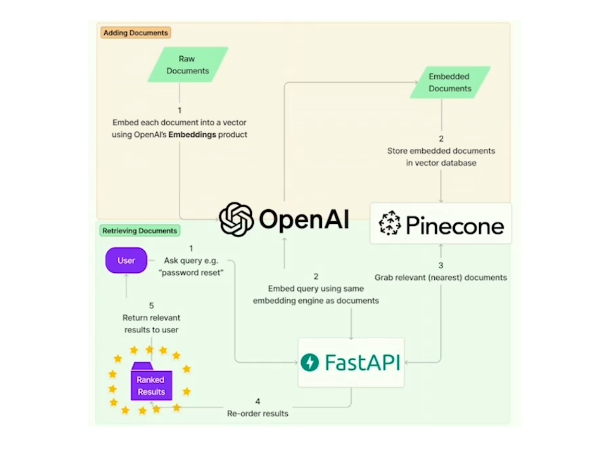

#Imports and Setups

In [6]:
%%capture
!pip install pinecone openai sentence-transformers tiktoken datasets

In [9]:
import hashlib
import re
import os
from tqdm import tqdm
import numpy as np
from torch import nn
from datetime import datetime, timezone
from google.colab import userdata

import logging
from sentence_transformers import CrossEncoder
from openai import OpenAI
from pinecone import Pinecone, ServerlessSpec

In [ ]:
logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)

In [30]:
#Get pre-stored api keys of both openai and pinecode vectorDB from notebook eniroment
client = OpenAI(
    api_key=userdata.get("OPENAI_API_KEY")
)

INDEX_NAME = 'semantic-search-test'
NAMESPACE = 'default'
ENGINE = 'text-embedding-3-large'

#Text Embedding Using OpenAI(ada3) API

In [11]:
# helper functions to get lists of embeddings from the OpenAI API
def get_embeddings(texts, engine=ENGINE):
    """
    Generates embeddings for a list of text strings using the OpenAI API(ada-3).

    Args:
        texts (list[str]): A list of text strings for which to generate embeddings.
        engine (str): The name of the OpenAI embeddings model to use. Defaults to ENGINE.

    Returns:
        list[list[float]]: A list of embedding vectors, where each vector corresponds
                           to an input text string.
    """
    response = client.embeddings.create(
        input=texts,
        model=engine
    )

    return [d.embedding for d in list(response.data)]

def get_embedding(text, engine=ENGINE):
    """
    Generates an embedding for a single text string using the OpenAI API.

    Args:
        text (str): The text string for which to generate the embedding.
        engine (str): The name of the OpenAI embeddings model to use. Defaults to ENGINE.

    Returns:
        list[float]: The embedding vector for the input text string.
    """
    return get_embeddings([text], engine)[0]

In [ ]:
print(get_embeddings(['hi', 'hello']))

#Pinecone setups

In [26]:
pinecone_key = userdata.get('PINECONE_API_KEY')
simmilarity_option = 'cosine'
vector_dim = 3072

pc = Pinecone(
    api_key= pinecone_key
)

In [27]:
if INDEX_NAME not in pc.list_indexes().names():

    print(f'Creating index {INDEX_NAME}')

    pc.create_index(
        name=INDEX_NAME,  # The name of the index
        dimension=vector_dim,  # The dimensionality of the vectors for our OpenAI embedder
        metric=simmilarity_option,  # The similarity metric to use when searching the index
        spec=ServerlessSpec(
            cloud='aws',
            region='us-east-1'
        )
    )

# Store the index as a variable
index = pc.Index(name=INDEX_NAME)
index

Creating index semantic-search-test


In [28]:
index.describe_index_stats()

{'dimension': 3072,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {},
 'total_vector_count': 0,
 'vector_type': 'dense'}

In [33]:
def my_hash(s):
    # Return the MD5 hash of the input string as a hexadecimal string
    return hashlib.md5(s.encode()).hexdigest()

my_hash('I love to hash it')

'ae76cc4dfd345ecaeea9b8ba0d5c3437'

In [34]:
def prepare_for_pinecone(texts, engine=ENGINE):
    """
    Prepares data for ingestion into Pinecone, generating unique IDs, embeddings,
    and metadata for a list of text strings.

    Args:
        texts (list[str]): A list of text strings to prepare for Pinecone.
        engine (str): The name of the OpenAI embeddings model to use. Defaults to ENGINE.

    Returns:
        list[tuple]: A list of tuples, where each tuple contains:
                     - A unique ID (MD5 hash of the text).
                     - The embedding vector for the text.
                     - A dictionary containing metadata (original text and upload date).
    """
    now = datetime.now(timezone.utc).isoformat()

    # Generate vector embeddings for each string in the input list using the specified engine
    embeddings = get_embeddings(texts, engine=engine)


    return [
        (
            my_hash(text),  # Unique ID (MD5 hash) for each text string
            embedding,  # Vector embedding of the text string
            dict(text=text, date_uploaded=now)  # Metadata dictionary
        )

        for text, embedding in zip(texts, embeddings)  # Iterate over each text and its corresponding embedding
    ]

In [ ]:
texts = ['hi']

_id, embedding, metadata = prepare_for_pinecone(texts)[0]

print('ID:  ',_id, '\nLEN: ', len(embedding), '\nMETA:', metadata)

In [36]:
def upload_texts_to_pinecone(texts, namespace=NAMESPACE, batch_size=None, show_progress_bar=False):
    """
    Uploads a list of text strings to a Pinecone index in batches.

    Args:
        texts (list[str]): A list of text strings to upload.
        namespace (str): The namespace within the Pinecone index to upload to.
                         Defaults to the value of the NAMESPACE constant.
        batch_size (int, optional): The number of texts to process in each batch.
                                     If None, all texts are processed in a single batch.
                                     Defaults to None.
        show_progress_bar (bool): Whether to display a progress bar during the upload.
                                 Defaults to False.

    Returns:
        int: The total number of vectors successfully upserted into the index.
    """
    total_upserted = 0

    if not batch_size:
        batch_size = len(texts)

    _range = range(0, len(texts), batch_size)

    for i in tqdm(_range) if show_progress_bar else _range:
        batch = texts[i: i + batch_size]
        prepared_texts = prepare_for_pinecone(batch)
        upsert_response = index.upsert(
            vectors=prepared_texts,
            namespace=namespace
        )

        total_upserted += upsert_response['upserted_count']

    return total_upserted

In [ ]:
upload_texts_to_pinecone(texts)

In [35]:
def query_from_pinecone(query, top_k=3, include_metadata=True):
    # get embedding from THE SAME embedder as the documents
    query_embedding = get_embedding(query, engine=ENGINE)

    return index.query(
      vector=query_embedding,
      top_k=top_k,
      namespace=NAMESPACE,
      include_metadata=include_metadata   # gets the metadata (dates, text, etc)
    ).get('matches')

def delete_texts_from_pinecone(texts, namespace=NAMESPACE):
    # Compute the hash (id) for each text
    hashes = [hashlib.md5(text.encode()).hexdigest() for text in texts]

    # The ids parameter is used to specify the list of IDs (hashes) to delete
    return index.delete(ids=hashes, namespace=namespace)

#Dataset Prepration

**Google-research/Xtreme**

The Cross-lingual TRansfer Evaluation of Multilingual Encoders (XTREME) benchmark is a benchmark for the evaluation of the cross-lingual generalization ability of pre-trained multilingual models. It covers 40 typologically diverse languages (spanning 12 language families) and includes nine tasks that collectively require reasoning about different levels of syntax and semantics. The languages in XTREME are selected to maximize language diversity, coverage in existing tasks, and availability of training data. Among these are many under-studied languages, such as the Dravidian languages Tamil (spoken in southern India, Sri Lanka, and Singapore), Telugu and Malayalam (spoken mainly in southern India), and the Niger-Congo languages Swahili and Yoruba, spoken in Africa.

In [37]:
from datasets import load_dataset

dataset = load_dataset("xtreme", "MLQA.en.en")

# rename test -> train and val -> test (as we will use it in later in this chapter)
dataset['train'] = dataset['test']
dataset['test'] = dataset['validation']
del dataset['validation']

dataset


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

MLQA.en.en/test-00000-of-00001.parquet:   0%|          | 0.00/7.49M [00:00<?, ?B/s]

MLQA.en.en/validation-00000-of-00001.par(…):   0%|          | 0.00/724k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/11590 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1148 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 1148
    })
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 11590
    })
})

In [40]:
print("Test Q/A 1:\n")
dataset['train'][0]

Test Q/A 1:



{'id': 'a4968ca8a18de16aa3859be760e43dbd3af3fce9',
 'title': 'Area 51',
 'context': 'In 1994, five unnamed civilian contractors and the widows of contractors Walter Kasza and Robert Frost sued the USAF and the United States Environmental Protection Agency. Their suit, in which they were represented by George Washington University law professor Jonathan Turley, alleged they had been present when large quantities of unknown chemicals had been burned in open pits and trenches at Groom. Biopsies taken from the complainants were analyzed by Rutgers University biochemists, who found high levels of dioxin, dibenzofuran, and trichloroethylene in their body fat. The complainants alleged they had sustained skin, liver, and respiratory injuries due to their work at Groom, and that this had contributed to the deaths of Frost and Kasza. The suit sought compensation for the injuries they had sustained, claiming the USAF had illegally handled toxic materials, and that the EPA had failed in its duty t

In [ ]:
#lets upload our dataset to pinecone
unique_passages = list(set(dataset['test']['context']))
for idx in tqdm(range(0, len(unique_passages), 32)):
    passages = unique_passages[idx:idx + 32]
    upload_texts_to_pinecone(passages)

#Checkout what hapened to our dataset
index.describe_index_stats()

#Test our embedding system and its informaiton retrival porcess

In [ ]:
query_from_pinecone('Who analyzed the biopsies?')

In [ ]:
query_from_pinecone('Does an infection for Sandflies go away over time?')